In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print("All libraries loaded successfully!")

base_path = "/kaggle/input/velocity-9/velocity_cls"
label_map = {
    "Fall": 0,
    "normal": 1,
    "unstable": 2
}


def get_avg_y(row, left_col, right_col, left_conf_col, right_conf_col, threshold=0.5):
    left_conf = row[left_conf_col]
    right_conf = row[right_conf_col]
    left_y = row[left_col]
    right_y = row[right_col]
    
    if left_conf > threshold and right_conf > threshold:
        return (left_y + right_y) / 2
    elif left_conf > threshold:
        return left_y
    elif right_conf > threshold:
        return right_y
    else:
        return np.nan

#Min-Max Normalization Function
def normalize_sequence_minmax(seq):
    seq = np.array(seq)
    min_val = np.min(seq)
    max_val = np.max(seq)
    if max_val == min_val:
        return np.zeros_like(seq)
    return (seq - min_val) / (max_val - min_val)


X = []
y = []
max_seq_len = 128

for label_name in label_map.keys():
    folder_path = os.path.join(base_path, label_name)
    
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)
            try:
                df = pd.read_csv(file_path)

                sequence = []

                for _, row in df.iterrows():
                    shoulder_y = get_avg_y(row, "left_shoulder_y", "right_shoulder_y",
                                                  "left_shoulder_conf", "right_shoulder_conf")
                    hip_y      = get_avg_y(row, "left_hip_y", "right_hip_y",
                                                  "left_hip_conf", "right_hip_conf")
                    knee_y     = get_avg_y(row, "left_knee_y", "right_knee_y",
                                                  "left_knee_conf", "right_knee_conf")
                    ankle_y    = get_avg_y(row, "left_ankle_y", "right_ankle_y",
                                                  "left_ankle_conf", "right_ankle_conf")
                    
                    if np.isnan([shoulder_y, hip_y, knee_y, ankle_y]).any():
                        continue  # skip this frame
                    
                    
                    frame = [shoulder_y, hip_y, knee_y, ankle_y]
                    sequence.append(frame)
                
                if len(sequence) < 5:
                    continue  # too short to be useful
                
                #Min-Max normalization to the full sequence
                sequence = normalize_sequence_minmax(sequence)
                    
                
                X.append(sequence)
                y.append(label_map[label_name])

            except Exception as e:
                print(f"❌ Error processing {file_path}: {e}")





All libraries loaded successfully!


In [ ]:

X_padded = pad_sequences(X, maxlen=max_seq_len, dtype='float32', padding='post', truncating='post')
y = np.array(y)

print("After padding:", X_padded.shape)

X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_train shape:", y_test.shape)



# Reshape for LSTM: (samples, time_steps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 4))

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 4))

import pandas as pd

# Flatten 3D LSTM input (128 timesteps × 4 features) → 2D (512 features)
X_train_flat = X_train.reshape((X_train.shape[0], -1))
X_test_flat  = X_test.reshape((X_test.shape[0], -1))

# Convert to DataFrames
df_X_train = pd.DataFrame(X_train_flat)
df_y_train = pd.DataFrame(y_train, columns=["label"])

df_X_test = pd.DataFrame(X_test_flat)
df_y_test = pd.DataFrame(y_test, columns=["label"])

# Save to CSV in Kaggle working directory
df_X_train.to_csv("/kaggle/working/X_train.csv", index=False)
df_y_train.to_csv("/kaggle/working/y_train.csv", index=False)
df_X_test.to_csv("/kaggle/working/X_test.csv", index=False)
df_y_test.to_csv("/kaggle/working/y_test.csv", index=False)

print("✅ All train/test splits saved as CSV.")

######################################################################

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("🔍 Computed class weights:", class_weight_dict)


After padding: (3441, 128, 4)
X_train shape: (2752, 128, 4)
X_test shape: (689, 128, 4)
y_train shape: (2752,)
y_train shape: (689,)
✅ All train/test splits saved as CSV.
🔍 Computed class weights: {0: 1.8494623655913978, 1: 0.5170988350244269, 2: 1.9031811894882433}


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:

model = Sequential()

# Mask padding values (0s) so LSTM ignores them
model.add(Masking(mask_value=0.0, input_shape=(X_train.shape[1], X_train.shape[2])))

# LSTM layer (can increase units later)
model.add(LSTM(64, return_sequences=False))

# Optional Dropout for regularization
model.add(Dropout(0.3))

# Dense output: 3 classes (fall, normal, unstable)
model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict            
)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1756833651.762202      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756833651.762893      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1756833655.375494      96 cuda_dnn.cc:529] Loaded cuDNN version 90300


69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5931 - loss: 0.9457 - val_accuracy: 0.8439 - val_loss: 0.4466
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7236 - loss: 0.6994 - val_accuracy: 0.8203 - val_loss: 0.4414
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8051 - loss: 0.5922 - val_accuracy: 0.8439 - val_loss: 0.4509
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8377 - loss: 0.4553 - val_accuracy: 0.8766 - val_loss: 0.3439
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8416 - loss: 0.4607 - val_accuracy: 0.8820 - val_loss: 0.3302
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8621 - loss: 0.3757 - val_accuracy: 0.8966 - val_loss: 0.3034
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8630 - loss: 0.4215 - val_accuracy: 0.9056 - val_loss: 0.2942
Epoch 8/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8693 - loss: 0.3883 - val_accuracy: 0.8984 - val_loss: 0.

In [10]:
# Training accuracy after final epoch
train_acc = history.history['accuracy'][-1]
print(f"✅ Training Accuracy: {train_acc:.4f}")

# Validation accuracy after final epoch
val_acc = history.history['val_accuracy'][-1]
print(f"✅ Validation Accuracy: {val_acc:.4f}")


✅ Training Accuracy: 0.8887
✅ Validation Accuracy: 0.9220


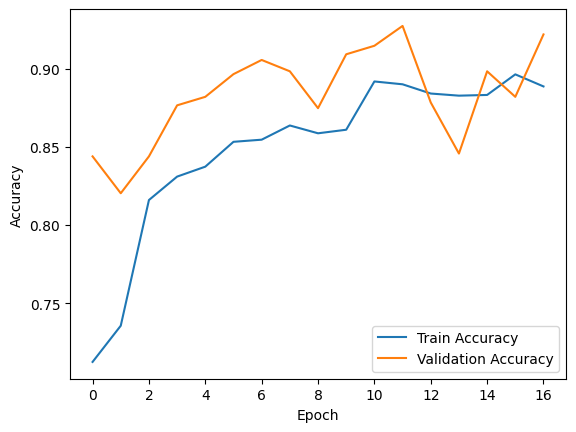

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [12]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {acc:.4f}")


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8832 - loss: 0.3113

✅ Test Accuracy: 0.9086


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [14]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["fall", "normal", "unstable"]))


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Confusion Matrix:
[[140   5  10]
 [  5 400  29]
 [  7   7  86]]

Classification Report:
              precision    recall  f1-score   support

        fall       0.92      0.90      0.91       155
      normal       0.97      0.92      0.95       434
    unstable       0.69      0.86      0.76       100

    accuracy                           0.91       689
   macro avg       0.86      0.89      0.87       689
weighted avg       0.92      0.91      0.91       689



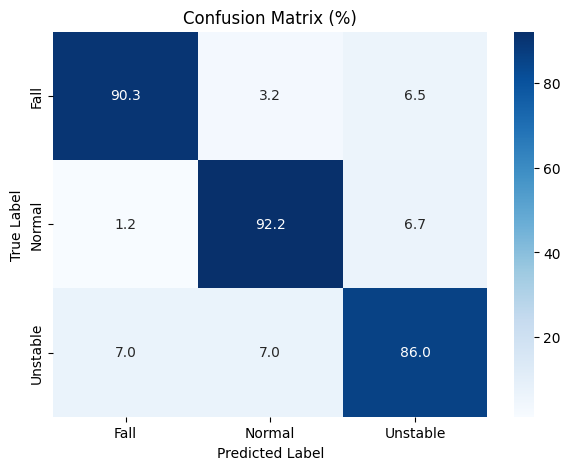

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Replace with your actual predictions and ground truth
# y_test = ... (true labels)
# y_pred = ... (predicted labels)

# Step 1: Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 2: Normalize row-wise (by true label count)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Step 3: Plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=["Fall", "Normal", "Unstable"], yticklabels=["Fall", "Normal", "Unstable"])
plt.title("Confusion Matrix (%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# Assuming you have trained a Keras model named 'model'
model.save('/kaggle/working/my_keras_model.h5')  # Save the model as an HDF5 file

# To load the model later
from tensorflow.keras.models import load_model
loaded_model = load_model('/kaggle/working/my_keras_model.h5')
